2025年保险行业AI应用全景洞察报告
https://report.iresearch.cn/report_pdf.aspx?id=4729

In [ ]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

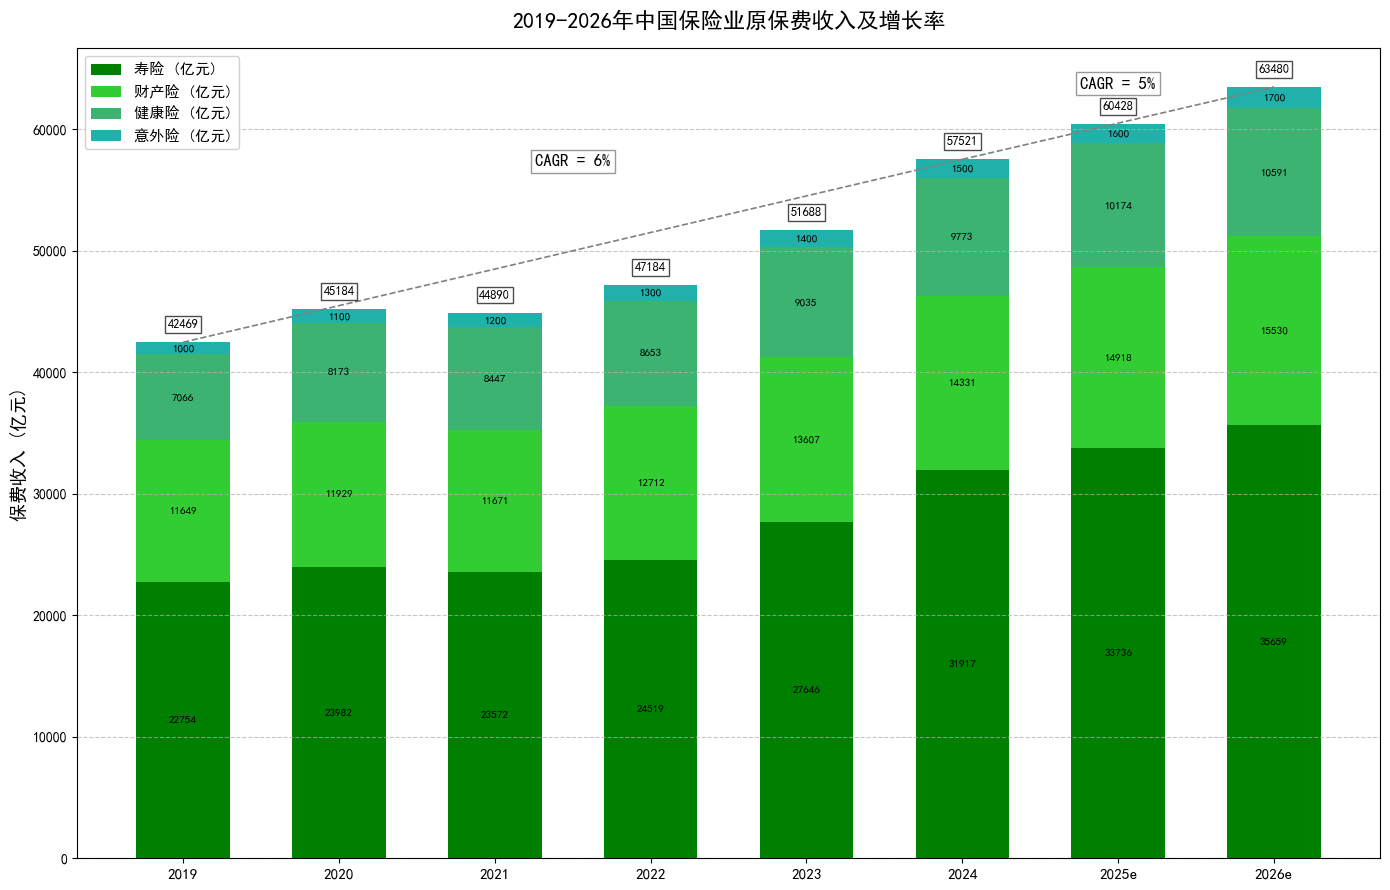

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 年份
years = ["2019", "2020", "2021", "2022", "2023", "2024", "2025e", "2026e"]
# 各险种保费收入（亿元），数据大体模拟，可根据实际调整
premium_data = np.array([
    [22754, 11649, 7066, 1000],    # 2019
    [23982, 11929, 8173, 1100],    # 2020
    [23572, 11671, 8447, 1200],    # 2021
    [24519, 12712, 8653, 1300],    # 2022
    [27646, 13607, 9035, 1400],    # 2023
    [31917, 14331, 9773, 1500],    # 2024
    [33736, 14918, 10174, 1600],   # 2025e
    [35659, 15530, 10591, 1700]    # 2026e
])

# 各险种对应的颜色
colors = ['green', 'limegreen', 'mediumseagreen', 'lightseagreen']
# 险种名称
insurance_types = ["寿险 (亿元)", "财产险 (亿元)", "健康险 (亿元)", "意外险 (亿元)"]

x = np.arange(len(years))  # x轴刻度位置
bar_width = 0.6  # 柱状图宽度

fig, ax = plt.subplots(figsize=(14, 9))  # 进一步增大图表尺寸

# 绘制堆积柱状图
bottom = np.zeros(len(years))
for i in range(premium_data.shape[1]):
    bars = ax.bar(x, premium_data[:, i], width=bar_width, bottom=bottom, color=colors[i], label=insurance_types[i])
    bottom += premium_data[:, i]
    
    # 在每个柱状图上方添加数据标签
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 500:  # 只显示高度足够的标签，避免拥挤
            ax.text(
                bar.get_x() + bar.get_width()/2., 
                bar.get_y() + height/2,
                f'{int(height)}',
                ha='center', va='center',
                color='black', fontsize=8, fontweight='bold'
            )

# 添加标题
ax.set_title('2019-2026年中国保险业原保费收入及增长率', fontsize=16, pad=15)

# 设置x轴刻度标签
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)

# 添加y轴标签
ax.set_ylabel('保费收入 (亿元)', fontsize=13)

# 添加图例
ax.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=11)

# 计算各年总保费
total_premiums = premium_data.sum(axis=1)

# 添加总保费标注
for i, total in enumerate(total_premiums):
    ax.text(x[i], total + 1000,  # 调整垂直位置，避免与柱状图重叠
            f'{int(total)}', 
            ha='center', va='bottom', 
            fontsize=9, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.7, pad=2.0))

# CAGR标注函数
def add_cagr_annotation(start_idx, end_idx, cagr_value, ax, x, total_premiums):
    """添加CAGR折线标注"""
    start_x = x[start_idx]
    end_x = x[end_idx]
    start_y = total_premiums[start_idx]
    end_y = total_premiums[end_idx]
    
    # 计算中间点位置
    mid_x = (start_x + end_x) / 2
    mid_y1 = start_y + (end_y - start_y) * 0.3
    mid_y2 = start_y + (end_y - start_y) * 0.7
    
    # 绘制折线
    ax.plot([start_x, end_x], [start_y, end_y], 
            'gray', linestyle='--', linewidth=1.2)
    
    # 添加CAGR文本
    text_x = mid_x
    text_y = mid_y2 + (end_y - start_y) * 0.25
    ax.text(text_x, text_y, f'CAGR = {cagr_value}%', 
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', pad=3.0))

# 添加2019-2024年CAGR标注
add_cagr_annotation(0, 5, 6, ax, x, total_premiums)

# 添加2024-2026年CAGR标注
add_cagr_annotation(5, 7, 5, ax, x, total_premiums)

# 美化图表
plt.grid(axis='y', linestyle='--', alpha=0.7)  # 添加水平网格线
plt.tight_layout()  # 自动调整布局

plt.show()

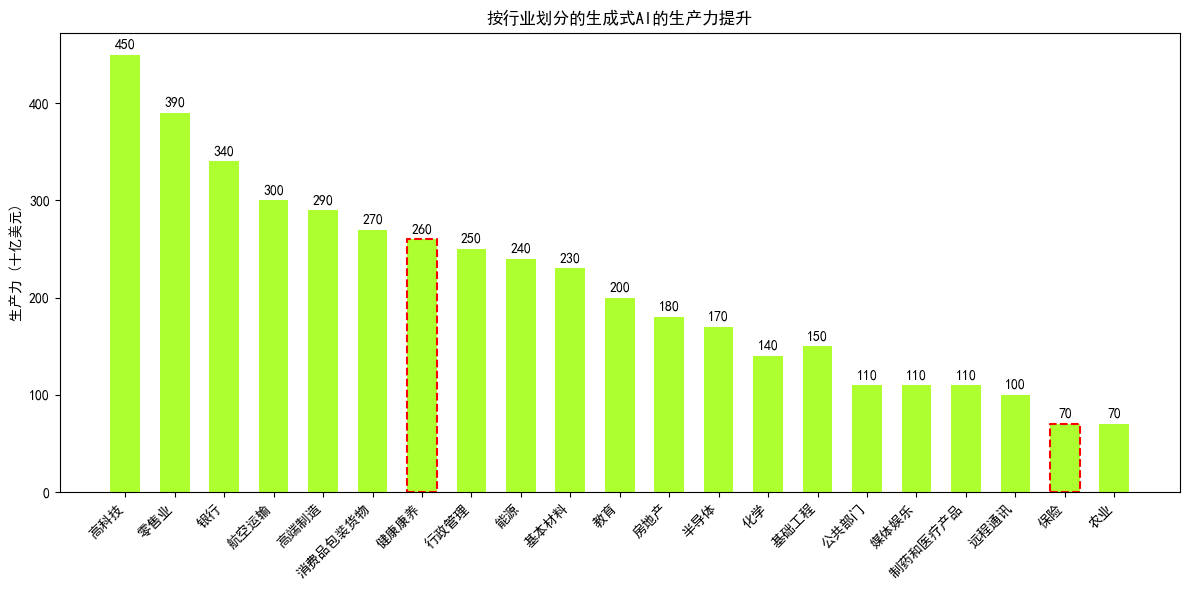

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 行业名称
industries = ["高科技", "零售业", "银行", "航空运输", "高端制造", "消费品包装货物", "健康康养", "行政管理", "能源", 
              "基本材料", "教育", "房地产", "半导体", "化学", "基础工程", "公共部门", "媒体娱乐", 
              "制药和医疗产品", "远程通讯", "保险", "农业"]
# 生产力数据（十亿美元），大体模拟，可根据实际调整
productivity = [450, 390, 340, 300, 290, 270, 260, 250, 240, 230, 200, 180, 170, 140, 150, 110, 110, 110, 100, 70, 70]
# 标记需要特殊框选的行业索引
special_indices = [6, 19]  # 健康康养、保险对应的索引

x = np.arange(len(industries))  # x 轴刻度位置
bar_width = 0.6  # 条形宽度

fig, ax = plt.subplots(figsize=(12, 6))

# 绘制条形图，颜色设置为接近的绿色
bars = ax.bar(x, productivity, width=bar_width, color='greenyellow')

# 添加标题
ax.set_title('按行业划分的生成式AI的生产力提升')

# 设置 x 轴刻度标签，旋转一定角度避免重叠
ax.set_xticks(x)
ax.set_xticklabels(industries, rotation=45, ha='right')

# 为特殊行业添加红色虚线框
for idx in special_indices:
    rect = bars[idx].get_bbox()
    ax.plot([rect.x0, rect.x1, rect.x1, rect.x0, rect.x0], 
            [rect.y0, rect.y0, rect.y1, rect.y1, rect.y0], 
            'r--', linewidth=1.5)

# 为每个条形添加数值标签
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 垂直偏移 3 个点
                textcoords="offset points",
                ha='center', va='bottom')

# 设置 y 轴标签
ax.set_ylabel('生产力 (十亿美元)')

plt.tight_layout()  # 自动调整布局，避免标签重叠
plt.show()

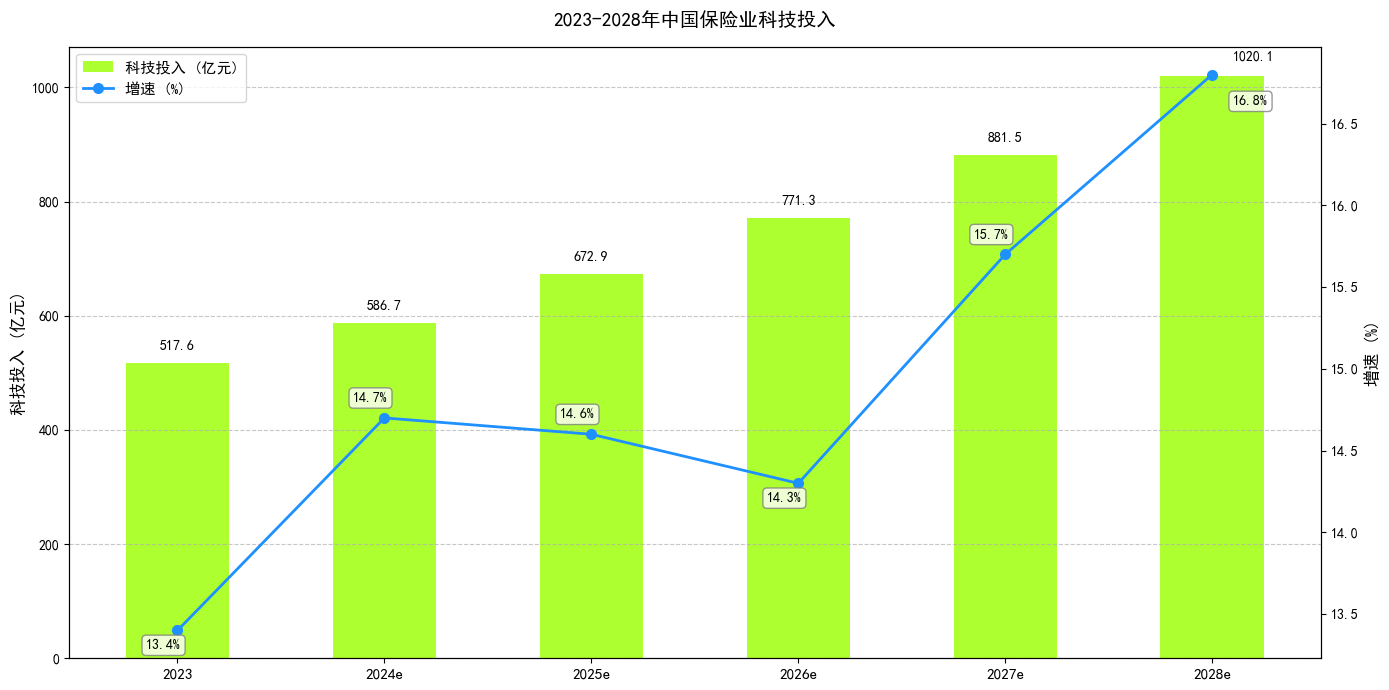

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 年份
years = ["2023", "2024e", "2025e", "2026e", "2027e", "2028e"]
# 科技投入（亿元），大体模拟，可根据实际调整
tech_investment = [517.6, 586.7, 672.9, 771.3, 881.5, 1020.1]
# 增速（%），大体模拟，可根据实际调整
growth_rate = [13.4, 14.7, 14.6, 14.3, 15.7, 16.8]

x = np.arange(len(years))  # x轴刻度位置
bar_width = 0.5  # 柱状图宽度

fig, ax1 = plt.subplots(figsize=(14, 7))  # 进一步增大图表宽度

# 绘制科技投入柱状图
bars = ax1.bar(x, tech_investment, width=bar_width, label='科技投入 (亿元)', color='greenyellow')
ax1.set_ylabel('科技投入 (亿元)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(years, fontsize=11)

# 为柱状图添加数值标签
for i, bar in enumerate(bars):
    height = bar.get_height()
    # 最后一个标签位置特殊处理
    if i == len(bars) - 1:
        ax1.annotate(f'{tech_investment[i]}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(15, 10),  # 向右上方偏移
                    textcoords="offset points",
                    ha='left', va='bottom',  # 左对齐，底部对齐
                    fontsize=10)
    else:
        ax1.annotate(f'{tech_investment[i]}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 8),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10)

# 创建第二个y轴，绘制增速折线图
ax2 = ax1.twinx()
line, = ax2.plot(x, growth_rate, marker='o', markersize=7, label='增速 (%)', 
                color='dodgerblue', linewidth=2)
ax2.set_ylabel('增速 (%)', fontsize=12)

# 为折线图添加数值标签
for i, rate in enumerate(growth_rate):
    # 最后一个标签位置特殊处理
    if i == len(growth_rate) - 1:
        ax2.annotate(f'{rate}%',
                    xy=(x[i], rate),
                    xytext=(15, -15),  # 向右下方偏移
                    textcoords="offset points",
                    ha='left', va='top',  # 左对齐，顶部对齐
                    fontsize=10,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    else:
        ax2.annotate(f'{rate}%',
                    xy=(x[i], rate),
                    xytext=(-10, 10) if rate > 14.5 else (-10, -15),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# 添加标题
ax1.set_title('2023-2028年中国保险业科技投入', fontsize=14, pad=15)

# 合并图例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

# 美化图表
ax1.grid(axis='y', linestyle='--', alpha=0.7)  # 添加水平网格线
plt.tight_layout()  # 自动调整布局

plt.show()

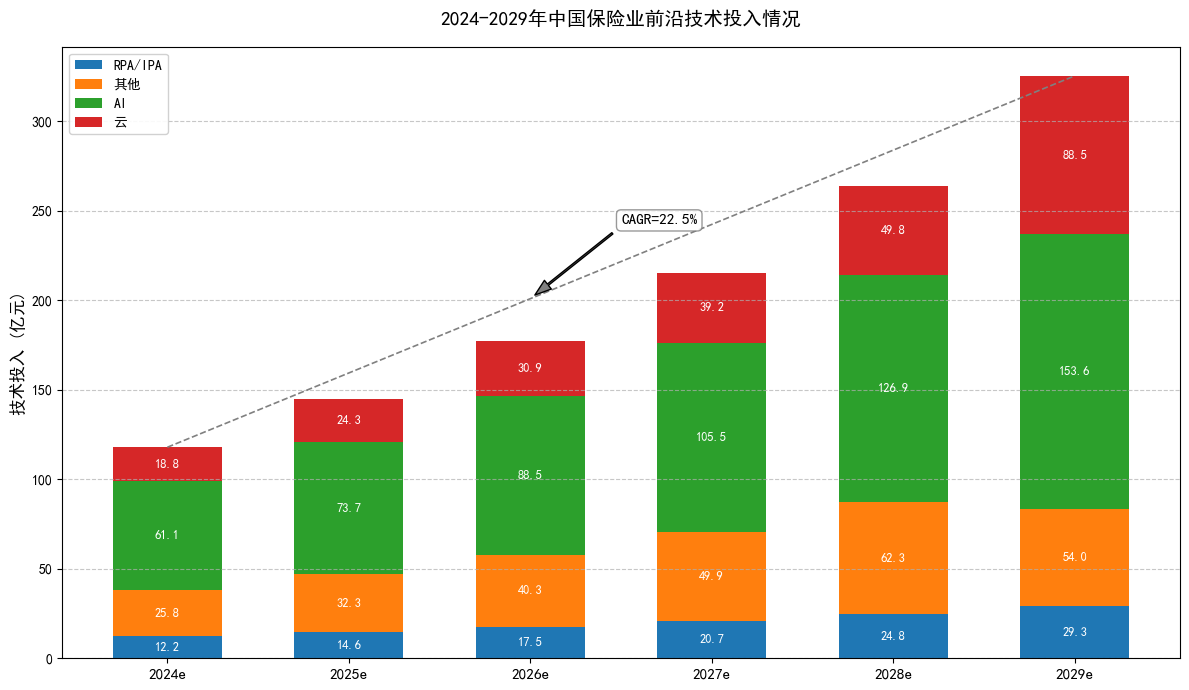

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 年份
years = ["2024e", "2025e", "2026e", "2027e", "2028e", "2029e"]

# 各技术投入数据（亿元），按 RPA/IPA、其他、AI、云、大数据 顺序
# 注意：最后一个值通过总和减去前面值计算，确保每层总和正确
tech_investment = np.array([
    [12.2, 25.8, 61.1, 117.9 - (12.2 + 25.8 + 61.1)],  # 2024e 总和: 12.2+25.8+61.1+18.8=117.9
    [14.6, 32.3, 73.7, 144.9 - (14.6 + 32.3 + 73.7)],  # 2025e 总和: 14.6+32.3+73.7+24.3=144.9
    [17.5, 40.3, 88.5, 177.2 - (17.5 + 40.3 + 88.5)],  # 2026e 总和: 17.5+40.3+88.5+30.9=177.2
    [20.7, 49.9, 105.5, 215.3 - (20.7 + 49.9 + 105.5)],# 2027e 总和: 20.7+49.9+105.5+39.2=215.3
    [24.8, 62.3, 126.9, 263.8 - (24.8 + 62.3 + 126.9)],# 2028e 总和: 24.8+62.3+126.9+50.0=263.8
    [29.3, 54.0, 153.6, 325.4 - (29.3 + 54.0 + 153.6)] # 2029e 总和: 29.3+54.0+153.6+88.5=325.4
])

# 各技术对应的颜色（尽量贴近原图）
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 技术名称（带单位）
tech_names = ["RPA/IPA", "其他", "AI", "云", "大数据"]

x = np.arange(len(years))  # x轴刻度位置
bar_width = 0.6  # 柱状图宽度

fig, ax = plt.subplots(figsize=(12, 7))

# 绘制堆积柱状图
bottom = np.zeros(len(years))
for i in range(tech_investment.shape[1]):
    bars = ax.bar(x, tech_investment[:, i], width=bar_width, bottom=bottom, 
                  color=colors[i], label=tech_names[i])
    bottom += tech_investment[:, i]
    
    # 在每个堆积层中标注数值
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:  # 只标注非零值
            ax.text(
                bar.get_x() + bar.get_width()/2, 
                bar.get_y() + height/2,
                f'{height:.1f}',
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold'
            )

# 添加标题
ax.set_title('2024-2029年中国保险业前沿技术投入情况', fontsize=14, pad=15)

# 设置x轴刻度标签
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)

# 添加y轴标签
ax.set_ylabel('技术投入 (亿元)', fontsize=12)

# 添加图例（放置在图表右侧）
ax.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=10)

# 计算并标注CAGR（22.5%）
cagr = 22.5
start_value = tech_investment[0].sum()
end_value = tech_investment[-1].sum()

# 绘制CAGR折线
ax.plot([x[0], x[-1]], [start_value, end_value], 'gray', linestyle='--', linewidth=1.2)

# 添加CAGR文本标注
ax.annotate(
    f'CAGR={cagr}%', 
    xy=(x[2], start_value + (end_value - start_value)*0.4), 
    xytext=(x[2]+0.5, start_value + (end_value - start_value)*0.6),
    arrowprops=dict(facecolor='gray', shrink=0.05, width=1.2, headwidth=8),
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

# 美化图表
plt.grid(axis='y', linestyle='--', alpha=0.7)  # 添加水平网格线
plt.tight_layout()  # 自动调整布局

plt.show()

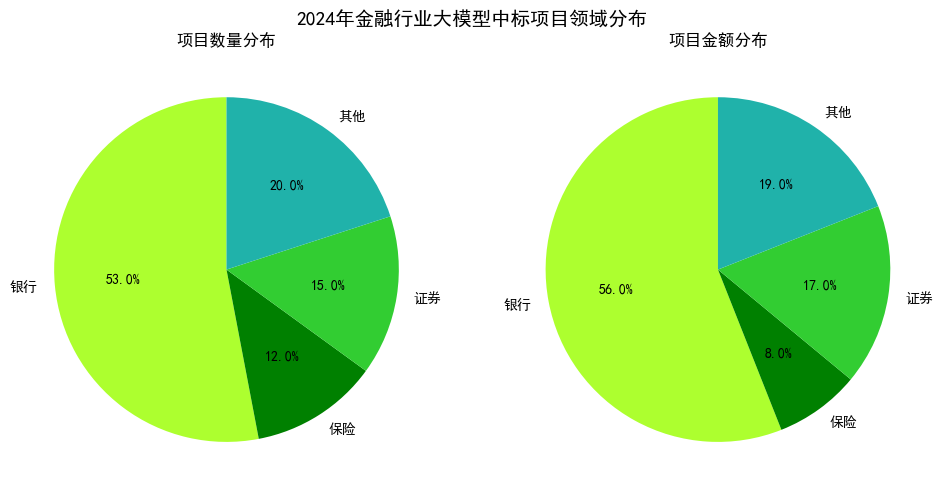

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 数据定义，项目数量分布和项目金额分布
labels = ["银行", "保险", "证券", "其他"]
sizes数量 = [53, 12, 15, 20]  # 项目数量分布，大体模拟
sizes金额 = [56, 8, 17, 19]  # 项目金额分布，大体模拟
# 颜色设置，尽量贴近原图
colors = ["greenyellow", "green", "limegreen", "lightseagreen"]

# 创建画布和子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# 绘制项目数量分布饼图
ax1.pie(sizes数量, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax1.set_title('项目数量分布')

# 绘制项目金额分布饼图
ax2.pie(sizes金额, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax2.set_title('项目金额分布')

# 添加主标题
fig.suptitle('2024年金融行业大模型中标项目领域分布', fontsize=14)

plt.tight_layout()
plt.show()